In [ ]:
from datasets import DatasetDict, Value, load_dataset

DATASET_REPO = "alexneo68/for_text_classification_food_not_food_v2"

dataset = load_dataset(path=DATASET_REPO)
print(dataset)

In [ ]:
# v2: label строковый, как в v1, поэтому пайплайн остаётся прежним. Но маппинг —
# константа, а не unique('label')[::-1]: в v1 он зависел от порядка строк и мог
# перевернуться молча.
id2label = {0: "not_food", 1: "food"}
label2id = {label: idx for idx, label in id2label.items()}

_feature = dataset["train"].features["label"]
_names = getattr(_feature, "names", None)
if _names is not None:                     # если вдруг ClassLabel, а не строка
    assert _names == list(id2label.values()), _names
else:
    assert sorted(set(dataset["train"]["label"])) == sorted(label2id), "неожиданные метки"

print(f"label to id mapping: {label2id}")
print(f"id to label mapping: {id2label}")

In [ ]:
# Границы train/validation/test/hard_test уже посчитаны по группам (одна сущность
# целиком в одном сплите) и лежат в колонке `split`. Меняешь только этот клет, если
# хочешь резать по-своему.
_pool = dataset["train"]


def sample_out_to_number(sample):
    return {"label": label2id[sample["label"]]}       # остальные колонки остаются


ds_number = DatasetDict({
    "train": _pool.filter(lambda s: s["split"] == "train"),
    "validation": _pool.filter(lambda s: s["split"] == "validation"),
    "test": _pool.filter(lambda s: s["split"] == "test"),
    "hard_test": _pool.filter(lambda s: s["split"] == "hard_test"),
}).map(sample_out_to_number)

# map не меняет тип уже существующей колонки: label осталась бы строкой "0"/"1",
# и модель получила бы строковые метки. Приводим явно.
ds_number = ds_number.cast_column("label", Value("int64"))
assert ds_number["train"].features["label"] == Value("int64"), ds_number["train"].features["label"]

print({k: len(v) for k, v in ds_number.items()})

In [ ]:
for _split, _ds in ds_number.items():
    assert sorted(set(_ds["label"])) == [0, 1], (_split, sorted(set(_ds["label"])))
    assert list(_ds["label"]) == list(_ds["label_id"]), _split

assert set(ds_number["hard_test"]["difficulty"]) == {"hard"}
print(ds_number["train"].features)

In [ ]:
ds_number["train"].shuffle()[:5]

In [ ]:
# Свой train_test_split(.2) больше не нужен и был вреден: он резал строки, поэтому
# одна и та же сущность попадала и в train, и в test. Метрика — отдельно на test
# и на hard_test (см. последнюю ячейку).

In [40]:
from transformers import AutoTokenizer
from pathlib import Path

model_save_dir = Path('models/food_not_food_text_classifier-DeepPavlov_rubert-base-cased')

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_save_dir, use_fast=True)

In [41]:
def text_tokenize(sample):
    return tokenizer(sample['caption'], truncation=True, padding=True)

In [42]:
tokenized_dataset = ds_number.map(function=text_tokenize, batched=True, batch_size=1000)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [43]:
import evaluate
import numpy as np
from typing import Tuple

accuracy_metric = evaluate.load("accuracy")

def accuracy_calc(predictions_and_labels: Tuple[np.array, np.array]):

    predictions, labels = predictions_and_labels

    if len(predictions.shape) >= 2:
        predictions = np.argmax(predictions, axis=1)

    return accuracy_metric.compute(predictions=predictions, references=labels)



In [44]:
e1 = np.array([0,0,0,0,0,0,0,0,0,0])
e2 = np.array([1,0,0,0,0,0,0,0,0,0])
lbs = np.array([0,0,0,0,0,0,0,0,0,0])

print(f"not_error: {accuracy_calc((e1, lbs))}")
print(f"1_error: {accuracy_calc((e2, lbs))}")

not_error: {'accuracy': 1.0}
1_error: {'accuracy': 0.9}


In [45]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path=model_save_dir, 
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [46]:
def count_of_model_params(model):
    trainable_params = sum([p.numel() for p in model.parameters() if p.requires_grad])
    total_parameters = sum([p.numel() for p in model.parameters()])

    return {'trainable_params': trainable_params, 'total_parameters': total_parameters}
    

In [47]:
count_of_model_params(model)

{'trainable_params': 177854978, 'total_parameters': 177854978}

In [54]:
from pathlib import Path

models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

model_save_name = "food_not_food_text_classifier-DeepPavlov_rubert-base-cased"
model_save_dir = Path(models_dir, model_save_name)

model_save_dir


PosixPath('models/food_not_food_text_classifier-DeepPavlov_rubert-base-cased')

In [48]:
from transformers import TrainingArguments

print(f"Save model in dir - {model_save_dir}")

trainings_args = TrainingArguments(
    output_dir=model_save_dir,
    learning_rate=0.0001,
    per_device_eval_batch_size=32,
    per_device_train_batch_size=32,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    use_cpu=False,
    seed=42,
    load_best_model_at_end=True,
    logging_strategy="epoch",
    report_to="none",
    # push_to_hub=True,
    # hub_token='',
    hub_private_repo=False

)

Save model in dir - models/food_not_food_text_classifier-DeepPavlov_rubert-base-cased


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=trainings_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    processing_class=tokenizer,
    compute_metrics=accuracy_calc
)

In [51]:
results = trainer.train()

/Users/makewww68/Documents/learning_projects/ml-text-classifications/.venv-hf/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.362133,0.586260,0.400000
2,0.189585,0.488343,0.940000
3,0.071710,0.013779,1.000000
4,0.000390,0.000248,1.000000
5,0.104996,0.002018,1.000000
6,0.027032,0.311760,0.960000
7,0.024682,0.164403,0.980000
8,0.025574,0.168269,0.980000
9,0.001286,0.172964,0.980000
10,0.000658,0.189532,0.960000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/makewww68/Documents/learning_projects/ml-text-classifications/.venv-hf/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/makewww68/Documents/learning_projects/ml-text-classifications/.venv-hf/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/makewww68/Documents/learning_projects/ml-text-classifications/.venv-hf/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [52]:
trainer.save_model(output_dir=model_save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [53]:
trainer_history_all = trainer.state.log_history
trainer_history_metrics = trainer_history_all[:-1]
trainer_history_training_time = trainer_history_all[-1]

In [55]:
import pprint

trainer_history_training_set = []
trainer_history_eval_set = []

for item in trainer_history_metrics:
    item_keys = item.keys()
    if any("eval" in item for item in item_keys):
        trainer_history_eval_set.append(item)
    else: 
        trainer_history_training_set.append(item)
pprint.pprint(trainer_history_training_set[:2])

[{'epoch': 1.0,
  'grad_norm': 24.357955932617188,
  'learning_rate': 9.142857142857143e-05,
  'loss': 0.362133264541626,
  'step': 7},
 {'epoch': 2.0,
  'grad_norm': 0.10601754486560822,
  'learning_rate': 8.142857142857143e-05,
  'loss': 0.1895847831453596,
  'step': 14}]


In [56]:
import pandas as pd

trainer_history_training_set_df = pd.DataFrame(trainer_history_training_set)
trainer_history_eval_set_df = pd.DataFrame(trainer_history_eval_set)

In [57]:
trainer_history_training_set_df.head()


,loss,grad_norm,learning_rate,epoch,step
0,0.362133,24.357956,0.000091,1.0,7
1,0.189585,0.106018,0.000081,2.0,14
2,0.071710,0.009663,0.000071,3.0,21
3,0.000390,0.008348,0.000061,4.0,28
4,0.104996,0.325600,0.000051,5.0,35


In [58]:
trainer_history_eval_set_df.head()

,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,0.586260,0.40,0.1248,400.717,16.029,1.0,7
1,0.488343,0.94,0.0490,1020.636,40.825,2.0,14
2,0.013779,1.00,0.0498,1004.196,40.168,3.0,21
3,0.000248,1.00,0.0442,1131.919,45.277,4.0,28
4,0.002018,1.00,0.0441,1134.074,45.363,5.0,35


In [59]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

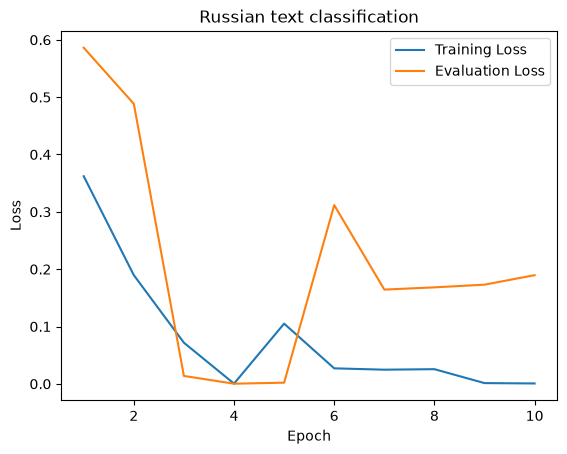

In [60]:
plt.plot(trainer_history_training_set_df['epoch'], trainer_history_training_set_df['loss'], label='Training Loss')
plt.plot(trainer_history_eval_set_df['epoch'], trainer_history_eval_set_df['eval_loss'], label='Evaluation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Russian text classification")
plt.legend()
plt.show()


In [61]:
model_upload_url = trainer.push_to_hub(
    commit_message='Дообученная модель по классификации текстов - съедобное/несъедобное. Предобученая модель - DeepPavlov/rubert-base-cased'
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [62]:
predictions_all = trainer.predict(tokenized_dataset['test'])


/Users/makewww68/Documents/learning_projects/ml-text-classifications/.venv-hf/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [63]:
prediction_values = predictions_all.predictions

In [64]:
prediction_metrics = predictions_all.metrics

In [65]:
prediction_metrics

{'test_loss': 0.00024817936355248094,
 'test_accuracy': 1.0,
 'test_runtime': 0.0786,
 'test_samples_per_second': 636.521,
 'test_steps_per_second': 25.461}

In [67]:
import torch
from sklearn.metrics import accuracy_score

In [74]:
pred_probs = torch.softmax(torch.tensor(prediction_values), dim=1)
pred_labels = torch.argmax(pred_probs, dim=1)
true_labels = torch.tensor(tokenized_dataset['test']['label'])

test_accuracy = accuracy_score(true_labels, pred_labels)

print(f"Test accuracy: {test_accuracy*100:.2f}%")


Test accuracy: 100.00%


In [76]:
test_predictions_df = pd.DataFrame({
    "caption": tokenized_dataset['test']['caption'],
    "true_label": true_labels,
    "pred_label": pred_labels,
    "pred_prob": torch.max(pred_probs, dim=1).values
})

test_predictions_df.head(10)

,caption,true_label,pred_label,pred_prob
0,Чемодан на колёсиках в коридоре.,0,0,0.999733
1,"Клубника в сливках, украшенная листиком мяты.",1,1,0.999760
2,"Пельмени, отварные, со сметаной.",1,1,0.999769
3,"Суп, куриный, с лапшой.",1,1,0.999770
4,"Яркая миска с морковью разных сортов, включая ...",1,1,0.999765
5,"Торшер у кресла, излучающий тёплый свет.",0,0,0.999725
6,Ботинки у порога.,0,0,0.999731
7,"Лайм, разрезанный на четвертинки, рядом с кокт...",1,1,0.999769
8,"Огурец, свежий и хрустящий, нарезанный соломкой.",1,1,0.999769
9,Чистящее средство в бутылке.,0,0,0.999729


In [78]:
test_predictions_df.sort_values(by='pred_prob', ascending=True).head(10)

,caption,true_label,pred_label,pred_prob
22,Ваза стеклянная с сухоцветами.,0,0,0.999667
40,Шланг поливочный свёрнутый.,0,0,0.999721
30,Полотенце махровое на крючке.,0,0,0.999724
5,"Торшер у кресла, излучающий тёплый свет.",0,0,0.999725
11,Песочница с лопатками.,0,0,0.999726
49,Блендер с чашей на базе.,0,0,0.999729
9,Чистящее средство в бутылке.,0,0,0.999729
15,"Ноутбук на столе, открытый с ярким экраном.",0,0,0.999730
6,Ботинки у порога.,0,0,0.999731
44,Тапочки домашние у кровати.,0,0,0.999731


In [ ]:
# метрика отдельно на test и hard_test: hard_test — это перенос значения
# (ложные друзья, метафоры, отрицания), на нём видно, выучила модель смысл или словарь
_hard = trainer.predict(tokenized_dataset['hard_test'])
_hard_probs = torch.softmax(torch.tensor(_hard.predictions), dim=1)
_hard_pred = torch.argmax(_hard_probs, dim=1)
_hard_true = torch.tensor(tokenized_dataset['hard_test']['label'])

hard_predictions_df = pd.DataFrame({
    "caption": tokenized_dataset['hard_test']['caption'],
    "true_label": [id2label[i] for i in _hard_true.tolist()],
    "pred_label": [id2label[i] for i in _hard_pred.tolist()],
    "pred_prob": torch.max(_hard_probs, dim=1).values,
})

print(f"test accuracy:      {test_accuracy*100:.2f}%  ({len(true_labels)} примеров)")
print(f"hard_test accuracy: {accuracy_score(_hard_true, _hard_pred)*100:.2f}%  ({len(_hard_true)} примеров)")

hard_predictions_df.sort_values(by='pred_prob').head(20)

In [81]:
huggingface_model_path = "alexneo68/food_not_food_text_classifier-DeepPavlov_rubert-base-cased"

In [84]:
def set_device():
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device('mps')
    else:
        device = torch.device('cpu')

    return device

DEVICE = set_device()

print(f"Установленное устройствоо: {DEVICE}")

Установленное устройствоо: mps


In [98]:
from transformers import pipeline

food_not_food_classification = pipeline(
    model=model_save_dir,
    task="text-classification",
    device=DEVICE,
    top_k=1,
    batch_size=32
)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [100]:
sentences = [
    "I whipped up a fresh batch of code, but it seems to have a syntax error.",
    "We need to marinate these ideas overnight before presenting them to the client.",
    "The new software is definitely a spicy upgrade, taking some time to get used to.",
    "Her social media post was the perfect recipe for a viral sensation.",
    "He served up a rebuttal full of facts, leaving his opponent speechless.",
    "The team needs to simmer down a bit before tackling the next challenge.",
    "The presentation was a delicious blend of humor and information, keeping the audience engaged.",
    "A beautiful array of fake wax foods (shokuhin sampuru) in the front of a Japanese restaurant.",
    "Daniel Bourke is really cool :D",
    "яблочный пирог!"
]

food_not_food_classification(sentences)

[[{'label': 'not_food', 'score': 0.7982410788536072}],
 [{'label': 'not_food', 'score': 0.9996649026870728}],
 [{'label': 'not_food', 'score': 0.9994916915893555}],
 [{'label': 'not_food', 'score': 0.9995852112770081}],
 [{'label': 'not_food', 'score': 0.9991357922554016}],
 [{'label': 'not_food', 'score': 0.9996962547302246}],
 [{'label': 'food', 'score': 0.9997307658195496}],
 [{'label': 'food', 'score': 0.9997243285179138}],
 [{'label': 'not_food', 'score': 0.99969482421875}],
 [{'label': 'not_food', 'score': 0.9996672868728638}]]

In [102]:
import time

sentences_1000 = sentences * 100

start_time = time.time()
for sentence in sentences_1000:
    food_not_food_classification(sentence)

end_time = time.time()


In [105]:
time_inference = end_time - start_time

avg_time_inference = time_inference/len(sentences_1000)

avg_time_inference

0.01178873896598816

In [106]:

times = {}
for i in [10, 100, 1000, 10000]:
    big_sentences = sentences * i

    start_time = time.time()

    food_not_food_classification(big_sentences)

    end_time = time.time()


    times[i] = end_time - start_time



In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from pathlib import Path

model_path = Path('models/food_not_food_text_classifier-DeepPavlov_rubert-base-cased')

sample_text_food = 'Эти груши лежат на белой тарелке'

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_path)
model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path=model_path)

inputs = tokenizer(sample_text_food, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [8]:
predicted_class_id = torch.argmax(outputs.logits, dim=1).item()
predicted_class_label = model.config.id2label[predicted_class_id]
predicted_probability = torch.softmax(outputs.logits, dim=1).max().item()

predicted_probability

0.9997186064720154

In [ ]:
import pprint
import numpy as np
from pathlib import Path
import torch

import datasets
import evaluate

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer


DATASET_NAME = ""
MODEL_NAME = "DeepPavlov/rubert-base-cased-sentence"
MODEL_SAVE_NAME = ""